Import current pipeline timing CSV

In [1]:
LOG_DIR = '../../experiments/current/'


In [2]:
# Parameters
LOG_DIR = "../../experiments/current/"


In [3]:
import pandas as pd
import os


long_term_memory = False

# Chargement du fichier CSV
df = pd.read_csv(LOG_DIR + 'pipeline_timing.csv')

colonnes_not_nan = df.columns[df.isna().all()==False]
df.drop(columns=['agent_id'], inplace=True)

if long_term_memory == False:
    df.drop(columns=['T_ltm_start', 'T_ltm_end'], inplace=True)


print("Na Columns: ")
print(df.columns[df.isna().all()])


print(df.isna().sum())


def _stat_path(title, ext="csv"):
    name = "".join(c if c.isalnum() or c in "-_" else "_" for c in title)
    img_dir = os.path.join(LOG_DIR, "images/pipeline")
    os.makedirs(img_dir, exist_ok=True)
    return os.path.join(img_dir, f"{name}.{ext}")


Na Columns: 
Index(['T_parse', 'T_osmnx_sem'], dtype='str')
sim_time                  0
T0                        0
T_parse                9748
T_flag                    0
T_otp_start             270
T_transit_sem          1607
T_transit_end          1607
T_osmnx_sem            9748
T_osmnx_end             296
T_otp_end               296
T_llm_start             301
T_llm_sent              309
T_llm_result            309
T_extract_end          5763
T_enqueue                36
T_fin                     0
P4_4_ms                9592
P5_1_ms                9592
P5_3_ms                9592
P5_4_ms                9592
P5_5_ms                9592
P5_llm_provider        9592
P5_llm_retries            0
P5_tokens_in              0
P5_tokens_out             0
plan_selected_index      26
selection_method         26
dtype: int64


Extract Date columns in df_delay

In [4]:
df_delay = df.drop(columns=['P4_4_ms', 'P5_1_ms', 'P5_3_ms', 'P5_4_ms',
       'P5_5_ms', 'P5_llm_provider', 'P5_llm_retries', 'P5_tokens_in',
       'P5_tokens_out'])

df_delay

,sim_time,T0,T_parse,T_flag,T_otp_start,T_transit_sem,T_transit_end,T_osmnx_sem,T_osmnx_end,T_otp_end,T_llm_start,T_llm_sent,T_llm_result,T_extract_end,T_enqueue,T_fin,plan_selected_index,selection_method
0,1773704999,1.780396e+09,NaN,1.780396e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.780396e+09,0.0,Pas de déplacement (même localisation)
1,1773704999,1.780396e+09,NaN,1.780396e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.780396e+09,0.0,Pas de déplacement (même localisation)
2,1773704999,1.780396e+09,NaN,1.780396e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.780396e+09,0.0,Pas de déplacement (même localisation)
3,1773704999,1.780396e+09,NaN,1.780396e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.780396e+09,0.0,Pas de déplacement (même localisation)
4,1773645280,1.780396e+09,NaN,1.780396e+09,1.780396e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.780396e+09,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9743,1774207686,1.780400e+09,NaN,1.780400e+09,1.780400e+09,NaN,NaN,NaN,1.780400e+09,1.780400e+09,1.780400e+09,1.780400e+09,1.780400e+09,NaN,1.780400e+09,1.780400e+09,0.0,LLM Error (Default index)
9744,1774168551,1.780400e+09,NaN,1.780400e+09,1.780400e+09,1.780400e+09,1.780400e+09,NaN,1.780400e+09,1.780400e+09,1.780400e+09,1.780400e+09,1.780400e+09,NaN,1.780400e+09,1.780400e+09,0.0,LLM Error (Default index)
9745,1774180417,1.780400e+09,NaN,1.780400e+09,1.780400e+09,1.780400e+09,1.780400e+09,NaN,1.780400e+09,1.780400e+09,1.780400e+09,1.780400e+09,1.780400e+09,NaN,1.780400e+09,1.780400e+09,0.0,LLM Error (Default index)
9746,1774168702,1.780400e+09,NaN,1.780400e+09,1.780400e+09,1.780400e+09,1.780400e+09,NaN,1.780400e+09,1.780400e+09,1.780400e+09,1.780400e+09,1.780400e+09,NaN,1.780400e+09,1.780400e+09,0.0,LLM Error (Default index)


Compute delays

In [5]:
df_delay["parse"]        = df_delay["T_parse"]       - df_delay["T0"]
df_delay["flag"]         = df_delay["T_flag"]        - df_delay["T_parse"]
df_delay["gap_otp"]      = df_delay["T_otp_start"]   - df_delay["T_flag"]
df_delay["transit_sem"]  = df_delay["T_transit_sem"] - df_delay["T_otp_start"]  # 3A queue
df_delay["transit_req"]  = df_delay["T_transit_end"] - df_delay["T_transit_sem"] # 3A HTTP
df_delay["transit"]      = df_delay["T_transit_end"] - df_delay["T_otp_start"]   # 3A total
df_delay["osmnx_sem"]    = df_delay["T_osmnx_sem"]   - df_delay["T_otp_start"]  # 3B queue (HTTP mode)
df_delay["osmnx_req"]    = df_delay["T_osmnx_end"]   - df_delay["T_osmnx_sem"]  # 3B processing (HTTP mode)
df_delay["osmnx"]        = df_delay["T_osmnx_end"]   - df_delay["T_otp_start"]  # 3B total
df_delay["otp"]          = df_delay["T_otp_end"]     - df_delay["T_otp_start"]  # 3 total = max(3A, 3B)
df_delay["gap_llm"]      = df_delay["T_llm_start"]   - df_delay["T_otp_end"]    # 3→5 transition
df_delay["llm_post"]     = df_delay["T_llm_sent"]    - df_delay["T_llm_start"]
df_delay["llm_wait"]     = df_delay["T_llm_result"]  - df_delay["T_llm_sent"]
df_delay["extract"]      = df_delay["T_extract_end"] - df_delay["T_llm_result"]
df_delay["enqueue"]      = df_delay["T_enqueue"]     - df_delay["T_extract_end"]
df_delay["ws"]           = df_delay["T_fin"]         - df_delay["T_enqueue"]
df_delay["total"]        = df_delay["T_fin"]         - df_delay["T0"]

if long_term_memory:
    df_delay["ltm"] = df_delay["T_ltm_end"] - df_delay["T_ltm_start"]

timestamp_cols = ["T_parse", "T_flag", "T_otp_start",
                  "T_transit_sem", "T_transit_end", "T_osmnx_sem", "T_osmnx_end", "T_otp_end",
                  "T_llm_start", "T_llm_sent", "T_llm_result", "T_extract_end", "T_enqueue"]
if long_term_memory:
    timestamp_cols += ["T_ltm_start", "T_ltm_end"]
df_delay = df_delay.drop(columns=[c for c in timestamp_cols if c in df_delay.columns])
df_delay

,sim_time,T0,T_fin,plan_selected_index,selection_method,parse,flag,gap_otp,transit_sem,transit_req,...,osmnx_req,osmnx,otp,gap_llm,llm_post,llm_wait,extract,enqueue,ws,total
0,1773704999,1.780396e+09,1.780396e+09,0.0,Pas de déplacement (même localisation),NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.227991
1,1773704999,1.780396e+09,1.780396e+09,0.0,Pas de déplacement (même localisation),NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.226243
2,1773704999,1.780396e+09,1.780396e+09,0.0,Pas de déplacement (même localisation),NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.224610
3,1773704999,1.780396e+09,1.780396e+09,0.0,Pas de déplacement (même localisation),NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.220352
4,1773645280,1.780396e+09,1.780396e+09,NaN,NaN,NaN,NaN,0.000020,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.216345
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9743,1774207686,1.780400e+09,1.780400e+09,0.0,LLM Error (Default index),NaN,NaN,0.000046,NaN,NaN,...,NaN,0.016083,0.143955,0.461043,0.0,6.224769,NaN,NaN,0.005872,264.015145
9744,1774168551,1.780400e+09,1.780400e+09,0.0,LLM Error (Default index),NaN,NaN,0.000031,0.000652,0.095817,...,NaN,0.001605,0.215984,0.289791,0.0,5.367850,NaN,NaN,0.001681,311.674289
9745,1774180417,1.780400e+09,1.780400e+09,0.0,LLM Error (Default index),NaN,NaN,0.000016,0.000162,0.066926,...,NaN,0.000579,0.082170,0.167727,0.0,5.024602,NaN,NaN,0.004713,75.538607
9746,1774168702,1.780400e+09,1.780400e+09,0.0,LLM Error (Default index),NaN,NaN,0.000026,0.000283,0.183884,...,NaN,0.001276,0.197498,0.105995,0.0,5.078586,NaN,NaN,0.001620,212.695556


In [6]:
delay_cols_ordered = [
    "parse",        # 1
    "flag",         # 2
    "gap_otp",      # 2→3
    "otp",          # 3 total
    "transit",      # 3A total
    "transit_sem",  # 3A-queue
    "transit_req",  # 3A-calc
    "osmnx",        # 3B total
    "osmnx_sem",    # 3B-queue (HTTP mode)
    "osmnx_req",    # 3B-calc (HTTP mode)
    "gap_llm",      # 3→5
    "llm_post",     # 5
    "llm_wait",     # 6
    "extract",      # 7
    "enqueue",      # 8
    "ws",           # 9
    "total",
]
if long_term_memory:
    delay_cols_ordered.insert(delay_cols_ordered.index("llm_post"), "ltm")

delay_cols_ordered = [c for c in delay_cols_ordered if c in df_delay.columns]

descriptions = {
    "parse":       "1     — Parsing JSON + validation Pydantic de la requête GAMA",
    "flag":        "2     — Filtrage des agents éligibles (scan de toute la population)",
    "gap_otp":     "2→3   — Délai asyncio entre lancement des tâches et démarrage OTP",
    "otp":         "3     — OTP + OSMnx gather total : durée = max(3A, 3B)",
    "transit":     "3A    — OTP transit total (queue + requête HTTP GraphQL)",
    "transit_sem": "3A-q  — Attente sémaphore OTP (queue, avant accès HTTP)",
    "transit_req": "3A-c  — Requête HTTP GraphQL OTP (calcul itinéraire transit)",
    "osmnx":       "3B    — OSMnx pied/vélo/voiture total (parallèle avec 3A)",
    "osmnx_sem":   "3B-q  — Attente sémaphore OSMnx (HTTP mode uniquement)",
    "osmnx_req":   "3B-c  — Calcul OSMnx après sémaphore (HTTP ou process pool)",
    "gap_llm":     "3→5   — Sélection candidats + construction payload LLM (non instrumenté)",
    "ltm":         "4     — Requête ChromaDB mémoire long terme (si LTM activée)",
    "llm_post":    "5     — HTTP POST création de la tâche dans le gateway LLM",
    "llm_wait":    "6     — Attente résultat LLM : long-poll Pub/Sub (micro-batch + worker + inférence)",
    "extract":     "7     — Extraction chosen_index + remapping vers le plan original (post-shuffle)",
    "enqueue":     "8     — Construction PersonMove + MoveLogger I/O + enqueue",
    "ws":          "9     — Attente envoi WebSocket vers GAMA (publish_loop)",
    "total":       "TOTAL — Durée totale pipeline T0 → T_fin",
}

delay_mean_df = df_delay[delay_cols_ordered].describe().loc[["mean", "std", "min", "max"]].T
delay_mean_df["Description"] = delay_mean_df.index.map(descriptions)
delay_mean_df.to_csv(_stat_path("pipeline_delay_summary"))
print(_stat_path("pipeline_delay_summary"))
delay_mean_df.style.format("{:.4f}", subset=["mean", "std", "min", "max"])


../../experiments/current/images/pipeline/pipeline_delay_summary.csv


,mean,std,min,max,Description
parse,nan,nan,nan,nan,1 — Parsing JSON + validation Pydantic de la requête GAMA
flag,nan,nan,nan,nan,2 — Filtrage des agents éligibles (scan de toute la population)
gap_otp,0.0000,0.0001,0.0000,0.0057,2→3 — Délai asyncio entre lancement des tâches et démarrage OTP
otp,1.0701,5.2513,0.0002,45.1339,"3 — OTP + OSMnx gather total : durée = max(3A, 3B)"
transit,1.1471,5.3101,0.0088,43.1551,3A — OTP transit total (queue + requête HTTP GraphQL)
transit_sem,0.8939,4.7816,0.0001,39.3236,"3A-q — Attente sémaphore OTP (queue, avant accès HTTP)"
transit_req,0.2532,0.8384,0.0087,11.0683,3A-c — Requête HTTP GraphQL OTP (calcul itinéraire transit)
osmnx,0.0095,0.0485,0.0001,2.6953,3B — OSMnx pied/vélo/voiture total (parallèle avec 3A)
osmnx_sem,nan,nan,nan,nan,3B-q — Attente sémaphore OSMnx (HTTP mode uniquement)
osmnx_req,nan,nan,nan,nan,3B-c — Calcul OSMnx après sémaphore (HTTP ou process pool)


Véfification que l'on a toutes les valeurs

In [7]:
# otp = total gather (transit+osmnx parallèles), transit/osmnx sont des sous-composantes
# gap_llm ferme le trou entre OTP et LLM
segment_cols = ["parse", "flag", "gap_otp", "otp", "gap_llm", "llm_post", "llm_wait", "extract", "enqueue", "ws"]
if long_term_memory:
    segment_cols.insert(segment_cols.index("llm_post"), "ltm")
segment_cols = [c for c in segment_cols if c in df_delay.columns]

df_llm = df_delay[df_delay["selection_method"] == "LLM"].copy()
df_llm["sum_segments"] = df_llm[segment_cols].sum(axis=1)
df_llm["diff"] = df_llm["total"] - df_llm["sum_segments"]

print(f"Lignes vérifiées (selection_method=LLM) : {len(df_llm)}")
print(f"Diff max  : {df_llm['diff'].abs().max():.4f} s")
print(f"Diff mean : {df_llm['diff'].abs().mean():.4f} s")
print()
df_llm[["total", "sum_segments", "diff"]].describe().style.format("{:.4f}")

Lignes vérifiées (selection_method=LLM) : 3960
Diff max  : 0.0000 s
Diff mean : 0.0000 s



,total,sum_segments,diff
count,3960.0000,3960.0000,3960.0000
mean,141.8942,141.8942,0.0000
std,144.0683,144.0683,0.0000
min,5.6335,5.6335,0.0000
25%,43.6605,43.6605,0.0000
50%,72.6274,72.6274,0.0000
75%,195.9983,195.9983,0.0000
max,831.1185,831.1185,0.0000


---
## Analyse temporelle — Débit, ratio et états des agents

In [8]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# --- moves.csv ---
moves_path = os.path.join(LOG_DIR, "moves.csv")
df_moves = pd.read_csv(moves_path) if os.path.exists(moves_path) else pd.DataFrame()
has_calc_time    = "Heure de calcul" in df_moves.columns
has_sim_time_col = "Temps simulé" in df_moves.columns
print(f"moves.csv : {len(df_moves)} lignes | Heure de calcul={has_calc_time} | Temps simulé={has_sim_time_col}")

# --- gama_arrivals.csv (retard réel à l'arrivée, calculé par GAMA) ---
arrivals_path = os.path.join(LOG_DIR, "gama_results", "gama_arrivals.csv")
df_arrivals = pd.read_csv(arrivals_path) if os.path.exists(arrivals_path) else pd.DataFrame()
print(f"gama_arrivals.csv : {len(df_arrivals)} lignes")

# --- agent_states.csv ---
states_path = os.path.join(LOG_DIR, "gama_results", "agent_states.csv")
df_states = pd.read_csv(states_path) if os.path.exists(states_path) else pd.DataFrame()
print(f"agent_states.csv : {len(df_states)} lignes | colonnes={list(df_states.columns) if not df_states.empty else '—'}")

moves.csv : 11065 lignes | Heure de calcul=True | Temps simulé=True
gama_arrivals.csv : 10227 lignes
agent_states.csv : 587 lignes | colonnes=['step', 'sim_timestamp', 'sim_time', 'inactive', 'ready', 'active', 'total']


In [9]:

df_arrivals["delay_min"] = (df_arrivals["delay_s"] / 60).clip(lower=0).astype(int)
df_arrivals


,move_id,person_id,arrive_at,expected_arrive_at,delay_s,started_at,schedule_at,departure_delay_s,delay_min
0,83cc7414-4ec2-4857-af41-72ecf544c303,993185,1773638957,1773638959,-2,1773637202,1773637940,-738,0
1,8204a3d6-ac87-4b48-a5dd-00683e8cc965,1230824,1773639353,1773640253,-900,1773637202,1773639353,-2151,0
2,e269e649-b0cb-4ec4-a526-6c60bcae0b9e,1032010,1773639594,1773640494,-900,1773637202,1773639594,-2392,0
3,eb368a09-23be-42e3-b32c-4a79ec653173,995100,1773639853,1773640753,-900,1773637202,1773639853,-2651,0
4,1db5b4da-0d07-46b5-8de6-fa15256ae7a4,789391,1773640173,1773640712,-539,1773637202,1773639812,-2610,0
...,...,...,...,...,...,...,...,...,...
10222,d6be908f-7ecd-43cd-ad23-e8d756965c87,1004220,1774165918,1774166818,-900,1774136401,1774165918,-29517,0
10223,78e6330e-a06b-4c18-9d08-1cf6b21f11bc,827124,1774165923,1774165924,-1,1774122820,1774164615,-41795,0
10224,38b2c90a-5369-483a-9005-da74e693f793,528404,1774165926,1774165927,-1,1774121512,1774163598,-42086,0
10225,b47c48ca-eb41-476c-a2c5-1358e089770e,1307105,1774165926,1774166269,-343,1774119683,1774165369,-45686,0


### 1. Débit par minute (temps réel) et retard de planification

Barres : nombre de trajets calculés par minute réelle (source : `T_fin` de pipeline_timing.csv).  
Axe secondaire : retard de planification moyen par minute (source : `Heure de calcul` + `Retard planification (s)` de moves.csv si disponibles, sinon durée pipeline totale comme proxy).

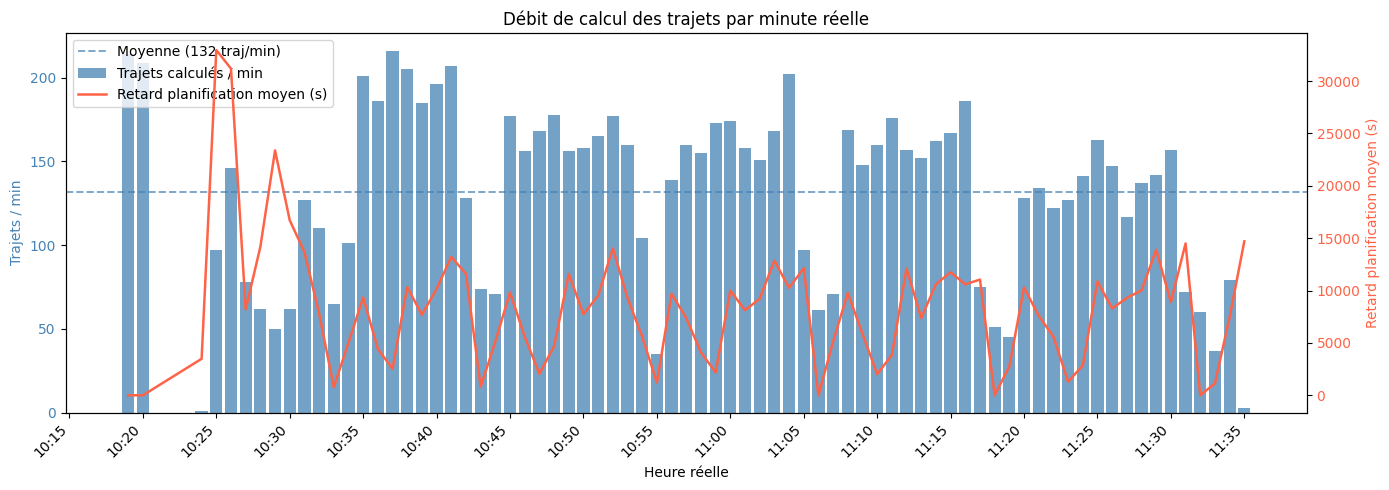

In [10]:
# --- Binning par minute réelle (T_fin depuis pipeline_timing) ---
df_rt = df_delay[["T_fin", "sim_time", "total"]].copy()
df_rt["real_dt"] = pd.to_datetime(df_rt["T_fin"], unit="s", utc=True)
df_rt["real_min"] = df_rt["real_dt"].dt.floor("min")

per_min = (
    df_rt.groupby("real_min")
    .agg(trips=("T_fin", "count"), avg_total=("total", "mean"))
    .reset_index()
    .sort_values("real_min")
)

# Retard de planification : moves.csv (Heure de calcul) si disponible, sinon total pipeline
if has_calc_time and "Retard planification (s)" in df_moves.columns:
    _m = df_moves.copy()
    _m["real_dt"] = pd.to_datetime(_m["Heure de calcul"], utc=True)
    _m["real_min"] = _m["real_dt"].dt.floor("min")
    _delay = _m.groupby("real_min")["Retard planification (s)"].mean().rename("avg_delay")
    per_min = per_min.join(_delay, on="real_min")
    delay_label_min = "Retard planification moyen (s)"
else:
    per_min["avg_delay"] = per_min["avg_total"]
    delay_label_min = "Durée pipeline moyenne (s) [proxy]"

mean_trips_min = per_min["trips"].mean()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

bar_width = pd.Timedelta(seconds=50)
ax1.bar(per_min["real_min"], per_min["trips"], width=bar_width,
        color="steelblue", alpha=0.75, label="Trajets calculés / min")
ax1.axhline(mean_trips_min, linestyle="--", color="steelblue", linewidth=1.4, alpha=0.7,
            label=f"Moyenne ({mean_trips_min:.0f} traj/min)")
ax2.plot(per_min["real_min"], per_min["avg_delay"],
         color="tomato", linewidth=1.8, label=delay_label_min)

ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax1.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha="right")

ax1.set_xlabel("Heure réelle")
ax1.set_ylabel("Trajets / min", color="steelblue")
ax2.set_ylabel(delay_label_min, color="tomato")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax2.tick_params(axis="y", labelcolor="tomato")
ax1.set_title("Débit de calcul des trajets par minute réelle")
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left")
fig.tight_layout()
plt.savefig(_stat_path("throughput_per_real_minute", "png"), dpi=150)
plt.show()

### 2. Débit par heure simulée et retard de planification

Barres : nombre de trajets calculés par heure simulée (source : `sim_time` de pipeline_timing.csv).  
Axe secondaire : retard de planification moyen par heure simulée (source : `Temps simulé` + `Retard planification (s)` de moves.csv si disponibles, sinon durée pipeline totale comme proxy).  
L'axe X est exprimé en heures simulées relatives au début de la simulation.

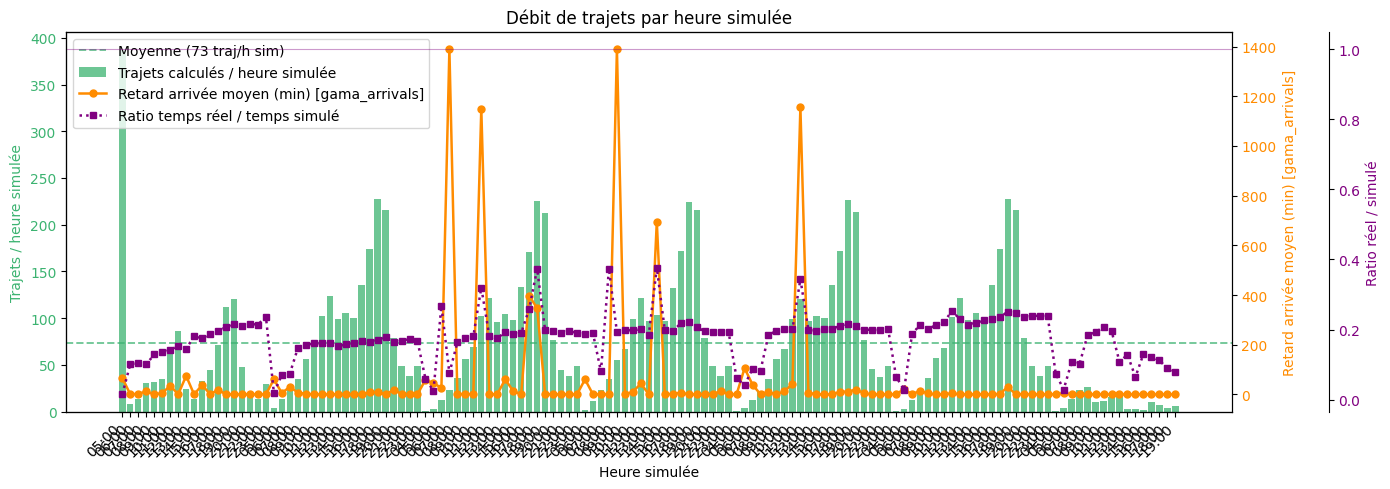

In [11]:
# --- Binning par heure simulée ---
sim_start = df_delay["sim_time"].min()

df_sh = df_delay[["sim_time", "total"]].copy()
df_sh["sim_hour"] = ((df_sh["sim_time"] - sim_start) / 3600).astype(int)

per_sim_hour = (
    df_sh.groupby("sim_hour")
    .agg(trips=("total", "count"), avg_total=("total", "mean"))
    .reset_index()
)

# Ratio temps réel / temps simulé : pour chaque heure simulée,
# on mesure la fenêtre réelle [min(T0), max(T_fin)] de toutes les tâches de cette heure
_real_span = df_delay[["T0", "T_fin", "sim_time"]].copy()
_real_span["sim_hour"] = ((_real_span["sim_time"] - sim_start) / 3600).astype(int)
_real_span = _real_span.groupby("sim_hour").agg(
    T0_min=("T0", "min"),
    T_fin_max=("T_fin", "max"),
).reset_index()
_real_span["real_elapsed"] = _real_span["T_fin_max"] - _real_span["T0_min"]
_real_span["ratio_real_sim"] = _real_span["real_elapsed"] / 3600.0
per_sim_hour = per_sim_hour.merge(_real_span[["sim_hour", "ratio_real_sim"]], on="sim_hour", how="left")

# Retard réel à l'arrivée : gama_arrivals.csv (delay_s = arrive_at - expected_arrive_at)
# Priorité : gama_arrivals > Temps simulé dans moves.csv > proxy total pipeline
if not df_arrivals.empty and "delay_s" in df_arrivals.columns:
    _arr = df_arrivals.copy()
    _arr["sim_hour"] = ((_arr["expected_arrive_at"] - sim_start) / 3600).astype(int)
    _delay_arr = (
        _arr[_arr["delay_s"] > 0]
        .groupby("sim_hour")["delay_s"]
        .mean()
        .rename("avg_delay")
    )
    per_sim_hour = per_sim_hour.join(_delay_arr, on="sim_hour")
    per_sim_hour["avg_delay"] = per_sim_hour["avg_delay"].fillna(0)/60
    delay_label_sh = "Retard arrivée moyen (min) [gama_arrivals]"
elif has_sim_time_col and "Retard planification (s)" in df_moves.columns:
    _ms = df_moves.copy()
    _ms["sim_hour"] = ((_ms["Temps simulé"] - sim_start) / 3600).astype(int)
    _delay_sh = _ms.groupby("sim_hour")["Retard planification (s)"].mean().rename("avg_delay")
    per_sim_hour = per_sim_hour.join(_delay_sh, on="sim_hour")
    per_sim_hour["avg_delay"] = per_sim_hour["avg_delay"].fillna(0)/60
    delay_label_sh = "Retard planification moyen (min) [gama_arrivals]"
else:
    per_sim_hour["avg_delay"] = per_sim_hour["avg_total"]
    delay_label_sh = "Durée pipeline moyenne (s) [proxy]"

mean_trips_sh = per_sim_hour["trips"].mean()

# Labels d'axe X : heure simulée absolue (HH:MM)
sim_hour_labels = [
    pd.Timestamp(sim_start + h * 3600, unit="s").strftime("%H:%M")
    for h in per_sim_hour["sim_hour"]
]

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("outward", 70))

x = np.arange(len(per_sim_hour))
ax1.bar(x, per_sim_hour["trips"], color="mediumseagreen", alpha=0.75, label="Trajets calculés / heure simulée")
ax1.axhline(mean_trips_sh, linestyle="--", color="mediumseagreen", linewidth=1.4, alpha=0.7,
            label=f"Moyenne ({mean_trips_sh:.0f} traj/h sim)")
ax2.plot(x, per_sim_hour["avg_delay"], color="darkorange",
         linewidth=1.8, marker="o", markersize=5, label=delay_label_sh)
ax3.plot(x, per_sim_hour["ratio_real_sim"], color="purple",
         linewidth=1.8, marker="s", markersize=4, linestyle=":",
         label="Ratio temps réel / temps simulé")
ax3.axhline(1.0, linestyle="-", color="purple", linewidth=0.8, alpha=0.4)

ax1.set_xticks(x)
ax1.set_xticklabels(sim_hour_labels, rotation=45, ha="right")
ax1.set_xlabel("Heure simulée")
ax1.set_ylabel("Trajets / heure simulée", color="mediumseagreen")
ax2.set_ylabel(delay_label_sh, color="darkorange")
ax3.set_ylabel("Ratio réel / simulé", color="purple")
ax1.tick_params(axis="y", labelcolor="mediumseagreen")
ax2.tick_params(axis="y", labelcolor="darkorange")
ax3.tick_params(axis="y", labelcolor="purple")
ax1.set_title("Débit de trajets par heure simulée")
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
h3, l3 = ax3.get_legend_handles_labels()
ax1.legend(h1 + h2 + h3, l1 + l2 + l3, loc="upper left")
fig.tight_layout()
plt.savefig(_stat_path("throughput_per_sim_hour", "png"), dpi=150)
plt.show()

In [12]:
per_sim_hour

,sim_hour,trips,avg_total,ratio_real_sim,avg_delay
0,0,387,44.171892,0.015411,66.316667
1,1,8,205.105184,0.101793,0.000000
2,2,14,207.147333,0.104946,2.100000
3,3,31,310.661408,0.100988,12.000000
4,4,32,262.306739,0.129307,0.000000
...,...,...,...,...,...
128,154,2,358.535107,0.130558,0.000000
129,155,10,209.259435,0.121939,0.000000
130,156,7,223.181397,0.112214,0.000000
131,157,4,170.594438,0.089441,0.000000


### 3. Évolution des états des agents (agent_states.csv)

Graphique en aires empilées : inactif / prêt / actif sur toute la durée de la simulation.

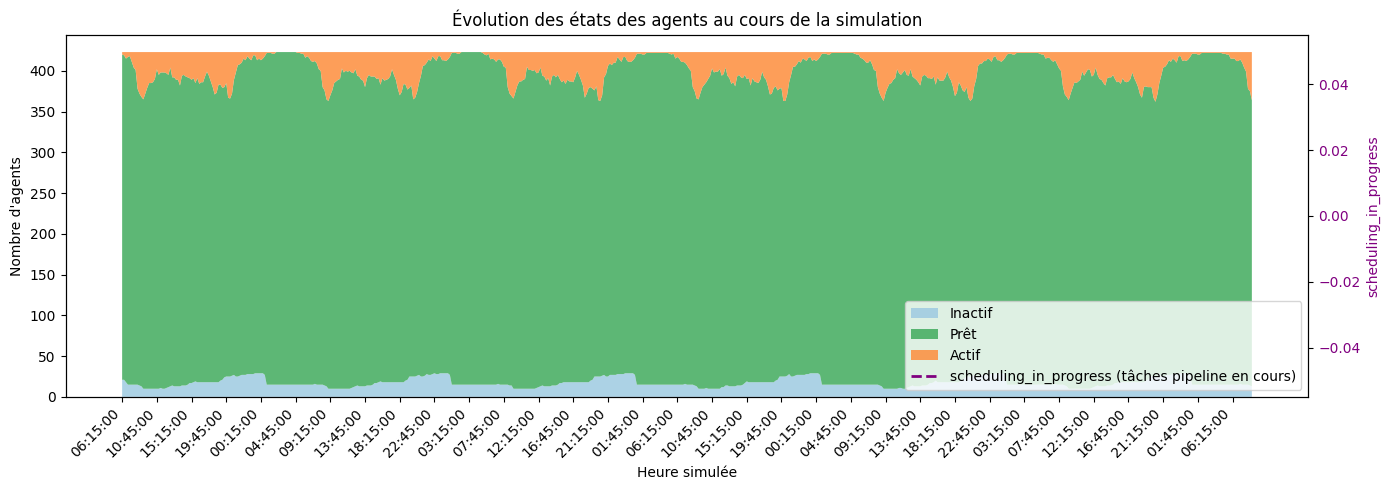

                        count        mean        std    min    25%    50%    75%    max
inactive                587.0   17.477002   5.718427   10.0   14.0   15.0   19.5   29.0
ready                   587.0  382.482112  17.768926  337.0  370.0  383.0  397.5  408.0
active                  587.0   23.040886  17.394392    0.0    7.0   23.0   36.0   61.0
scheduling_in_progress   22.0    0.000000   0.000000    0.0    0.0    0.0    0.0    0.0
total                   587.0  423.000000   0.000000  423.0  423.0  423.0  423.0  423.0


In [13]:
if df_states.empty:
    print("agent_states.csv introuvable — section ignorée")
else:
    # --- Calcul scheduling_in_progress par sync ---
    # T_flag est reconstruit : T0 + parse + flag (tous disponibles dans df_delay)
    # scheduling_in_progress = True sur l'intervalle [T_flag_abs, T_fin] pour chaque tâche
    _tasks = df_delay[["T0", "T_fin", "parse", "flag", "sim_time"]].copy()
    _tasks["T_flag_abs"] = _tasks["T0"] + _tasks["parse"] + _tasks["flag"]
    _tf = _tasks[["T_flag_abs", "T_fin"]].dropna()

    # Temps réel (wall clock) de chaque sync = T0 minimal observé pour ce sim_time
    _sync_wall = df_delay.groupby("sim_time")["T0"].min().reset_index()
    _sync_wall.columns = ["sim_timestamp", "T_sync_wall"]

    df_states_ext = df_states.merge(_sync_wall, on="sim_timestamp", how="left")

    def _count_in_progress(t):
        if pd.isna(t):
            return None
        return int(((_tf["T_flag_abs"] <= t) & (_tf["T_fin"] >= t)).sum())

    df_states_ext["scheduling_in_progress"] = df_states_ext["T_sync_wall"].apply(_count_in_progress)

    # --- Graphique ---
    fig, ax1 = plt.subplots(figsize=(14, 5))
    ax2 = ax1.twinx()

    ax1.stackplot(
        df_states_ext["sim_timestamp"],
        df_states_ext["inactive"],
        df_states_ext["ready"],
        df_states_ext["active"],
        labels=["Inactif", "Prêt", "Actif"],
        colors=["#9ecae1", "#41ab5d", "#fd8d3c"],
        alpha=0.85,
    )

    ax2.plot(
        df_states_ext["sim_timestamp"],
        df_states_ext["scheduling_in_progress"],
        color="purple", linewidth=2, linestyle="--",
        label="scheduling_in_progress (tâches pipeline en cours)",
    )

    tick_step = max(1, len(df_states_ext) // 32)
    tick_pos  = df_states_ext["sim_timestamp"].iloc[::tick_step].values
    tick_lbl  = df_states_ext["sim_time"].iloc[::tick_step].values
    ax1.set_xticks(tick_pos)
    ax1.set_xticklabels(tick_lbl, rotation=45, ha="right")

    ax1.set_xlabel("Heure simulée")
    ax1.set_ylabel("Nombre d'agents")
    ax2.set_ylabel("scheduling_in_progress", color="purple")
    ax2.tick_params(axis="y", labelcolor="purple")
    ax1.set_title("Évolution des états des agents au cours de la simulation")

    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc="lower right")
    fig.tight_layout()
    
    # ax1.set_xlim(650000, 750000)
    plt.savefig(_stat_path("agent_states_evolution", "png"), dpi=150)
    plt.show()

    print(df_states_ext[["sim_time", "inactive", "ready", "active", "scheduling_in_progress", "total"]]
          .set_index("sim_time").describe().T.to_string())

In [14]:
df_states

,step,sim_timestamp,sim_time,inactive,ready,active,total
0,1,1773638100,06:15:00,21,399,3,423
1,2,1773639000,06:30:00,21,398,4,423
2,3,1773639900,06:45:00,18,397,8,423
3,4,1773640800,07:00:00,15,402,6,423
4,5,1773641700,07:15:00,15,403,5,423
...,...,...,...,...,...,...,...
582,583,1774161900,07:45:00,15,389,19,423
583,584,1774162800,08:00:00,15,384,24,423
584,585,1774163700,08:15:00,15,363,45,423
585,586,1774164600,08:30:00,14,361,48,423


### 4. Ponctualité des arrivées (retard réel dans GAMA)

Répartition des trajets de `gama_arrivals.csv` selon le retard d'arrivée mesuré par GAMA :
- **Arrivé à l'heure** : `delay_s ≤ 0` (arrivée avant ou à l'heure prévue)  
- **Quart d'heure toulousain** : `0 < delay_s < 15 min`  
- **En retard** : `delay_s ≥ 15 min`


Total trajets analysés : 10227



,Catégorie,Nombre,Pourcentage (%)
0,Arrivé à l'heure (≤ 0 s),10139,99.1
1,Quart d'heure toulousain (< 15 min),53,0.5
2,En retard (≥ 15 min),35,0.3


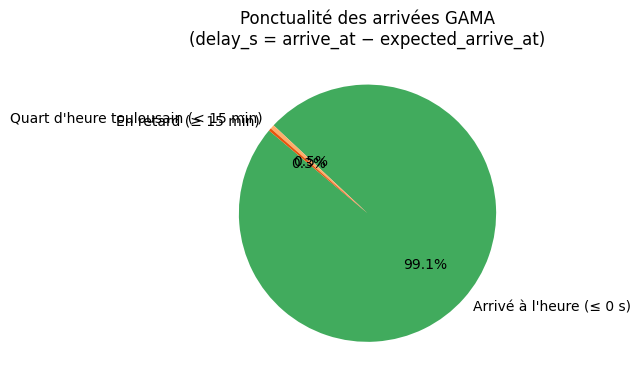

../../experiments/current/images/pipeline/ponctualite_arrivees.csv


In [15]:
if df_arrivals.empty or "delay_s" not in df_arrivals.columns:
    print("gama_arrivals.csv introuvable ou colonne delay_s absente — section ignorée")
else:
    retard = df_arrivals["delay_s"].dropna()
    total = len(retard)

    a_l_heure      = (retard <= 0).sum()
    quart_toulouse = ((retard > 0) & (retard < 15 * 60)).sum()
    en_retard      = (retard >= 15 * 60).sum()

    ponctualite = pd.DataFrame({
        "Catégorie": ["Arrivé à l'heure (≤ 0 s)", "Quart d'heure toulousain (< 15 min)", "En retard (≥ 15 min)"],
        "Nombre": [a_l_heure, quart_toulouse, en_retard],
        "Pourcentage (%)": [
            100 * a_l_heure / total,
            100 * quart_toulouse / total,
            100 * en_retard / total,
        ],
    })
    print(f"Total trajets analysés : {total}\n")
    display(ponctualite.style.format({"Pourcentage (%)": "{:.1f}"}))

    # Diagramme camembert
    fig, ax = plt.subplots(figsize=(6, 6))
    colors = ["#41ab5d", "#fdae6b", "#e6550d"]
    wedges, texts, autotexts = ax.pie(
        ponctualite["Nombre"],
        labels=ponctualite["Catégorie"],
        autopct="%1.1f%%",
        colors=colors,
        startangle=140,
    )
    ax.set_title("Ponctualité des arrivées GAMA\n(delay_s = arrive_at − expected_arrive_at)")
    fig.tight_layout()
    plt.savefig(_stat_path("ponctualite_arrivees", "png"), dpi=150)
    plt.show()

    ponctualite.to_csv(_stat_path("ponctualite_arrivees"), index=False)
    print(_stat_path("ponctualite_arrivees"))


### 4b. Historique des déplacements des agents en retard (≥ 15 min)

Pour chaque agent ayant au moins un trajet en retard, on affiche l'ensemble de ses trajets
(enrichis avec le mode, le motif et l'heure de départ de `moves.csv`).


In [16]:
if df_arrivals.empty or "delay_s" not in df_arrivals.columns:
    print("gama_arrivals.csv introuvable — section ignorée")
else:
    LATE_THRESHOLD_S = 15 * 60
    SECONDS_IN_DAY = 86400

    def _fmt_ts(ts):
        if pd.isna(ts):
            return ""
        s = int(ts) % SECONDS_IN_DAY
        return f"{s // 3600:02d}h{(s % 3600) // 60:02d}"

    def _fmt_delay(s):
        if pd.isna(s):
            return "N/A"
        s = int(s)
        sign = "+" if s >= 0 else "-"
        s = abs(s)
        return f"{sign}{s // 60}min{s % 60:02d}s"

    # 1. Identifier les agents avec au moins un trajet très en retard
    late_person_ids = df_arrivals.loc[
        df_arrivals["delay_s"] >= LATE_THRESHOLD_S, "person_id"
    ].unique()
    print(f"Agents avec ≥1 trajet en retard (≥15 min) : {len(late_person_ids)}")

    # 2. Tous les trajets de ces agents
    df_hist = df_arrivals[df_arrivals["person_id"].isin(late_person_ids)].copy()

    # 3. Enrichissement via moves.csv
    cols_moves = ["ID Trajet", "Mode de transport Choisi", "Motifs de déplacement",
                  "Heure de départ", "Retard planification (s)", "Méthode de sélection"]
    cols_moves = [c for c in cols_moves if c in df_moves.columns]
    if cols_moves:
        df_hist = df_hist.merge(
            df_moves[cols_moves].rename(columns={"ID Trajet": "move_id"}),
            on="move_id", how="left"
        )

    # 4. Colonnes lisibles
    df_hist["heure prévue départ"]   = df_hist["schedule_at"].apply(_fmt_ts) if "schedule_at" in df_hist.columns else "N/A"
    df_hist["heure réelle départ"]   = df_hist["started_at"].apply(_fmt_ts) if "started_at" in df_hist.columns else "N/A"
    df_hist["retard départ GAMA"]    = df_hist["departure_delay_s"].apply(_fmt_delay) if "departure_delay_s" in df_hist.columns else "N/A"
    df_hist["arrivée prévue"]        = df_hist["expected_arrive_at"].apply(_fmt_ts)
    df_hist["arrivée réelle"]        = df_hist["arrive_at"].apply(_fmt_ts)
    df_hist["retard arrivée"]        = df_hist["delay_s"].apply(_fmt_delay)
    df_hist["🔴 retard >15min"]     = df_hist["delay_s"] >= LATE_THRESHOLD_S

    df_hist = df_hist.sort_values(["person_id", "expected_arrive_at"])

    display_cols = ["person_id",
                    "heure prévue départ", "heure réelle départ", "retard départ GAMA",
                    "arrivée prévue", "arrivée réelle", "retard arrivée",
                    "🔴 retard >15min"]
    if "Mode de transport Choisi" in df_hist.columns:
        display_cols.insert(1, "Mode de transport Choisi")
    if "Motifs de déplacement" in df_hist.columns:
        display_cols.insert(2, "Motifs de déplacement")

    def _highlight_late(row):
        color = "background-color: #ffe0e0" if row["🔴 retard >15min"] else ""
        return [color] * len(row)

    styled = (
        df_hist[display_cols]
        .style
        .apply(_highlight_late, axis=1)
        .set_caption(f"Historique complet — {len(late_person_ids)} agents concernés")
    )
    display(styled)

    df_hist[display_cols].to_csv(_stat_path("late_agents_history"), index=False)
    print(_stat_path("late_agents_history"))


Agents avec ≥1 trajet en retard (≥15 min) : 17


,person_id,Mode de transport Choisi,Motifs de déplacement,heure prévue départ,heure réelle départ,retard départ GAMA,arrivée prévue,arrivée réelle,retard arrivée,🔴 retard >15min
5,11218,Voiture Privée,home,05h07,05h00,-7min09s,05h36,06h42,+66min19s,True
10,11218,Vélo,Travail,06h40,06h42,+2min08s,07h38,07h41,+2min06s,False
31,11218,Voiture Privée,other,11h54,07h41,-253min12s,12h09,12h09,-0min15s,False
39,11218,Voiture Privée,home,12h59,12h09,-49min59s,13h27,13h27,-0min01s,False
50,11218,Voiture Privée,Travail,14h31,13h27,-63min41s,14h58,14h58,+0min00s,False
71,11218,Voiture Privée,home,17h06,14h58,-128min40s,17h39,17h39,-0min01s,False
82,11218,Voiture Privée,other,18h41,17h39,-61min44s,18h56,18h50,-6min21s,False
87,11218,Voiture Privée,home,19h33,18h50,-43min34s,19h48,19h42,-6min28s,False
90,11218,Voiture Privée,other,20h28,19h42,-46min02s,20h43,20h39,-4min03s,False
92,11218,Voiture Privée,home,21h25,20h39,-46min05s,21h40,21h36,-4min03s,False


../../experiments/current/images/pipeline/late_agents_history.csv
